# Phase 4: Exploratory Data Analysis

Demographics, risk-factor distributions, discomfort prevalence. Figures saved to outputs/figures/.

## Step 0 — Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

CWD = Path.cwd()
ROOT = CWD if (CWD / 'data').exists() else CWD.parent
df   = pd.read_csv(ROOT / 'data' / 'processed' / 'model_ready.csv')
risk = pd.read_csv(ROOT / 'data' / 'processed' / 'risk_profile.csv')
FIGS = ROOT / 'outputs' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

print('model_ready :', df.shape)
print('risk_profile:', risk.shape)

model_ready : (182, 121)
risk_profile: (182, 14)


## Step 1 — Quick overview

In [2]:
assert len(df) == len(risk) == 182

risk_cols = ['force_risk', 'repetition_risk', 'duration_risk',
             'vibration_risk', 'contact_stress_risk', 'posture_risk']
{c: risk[c].value_counts().to_dict() for c in risk_cols}

{'force_risk': {'Low': 90, 'Medium': 57, 'High': 35},
 'repetition_risk': {'Medium': 82, 'High': 74, 'Low': 26},
 'duration_risk': {'High': 89, 'Medium': 56, 'Low': 37},
 'vibration_risk': {'Medium': 68, 'Low': 67, 'High': 47},
 'contact_stress_risk': {'Low': 68, 'Medium': 58, 'High': 56},
 'posture_risk': {'High': 153, 'Medium': 29}}

## Step 2 — Demographics

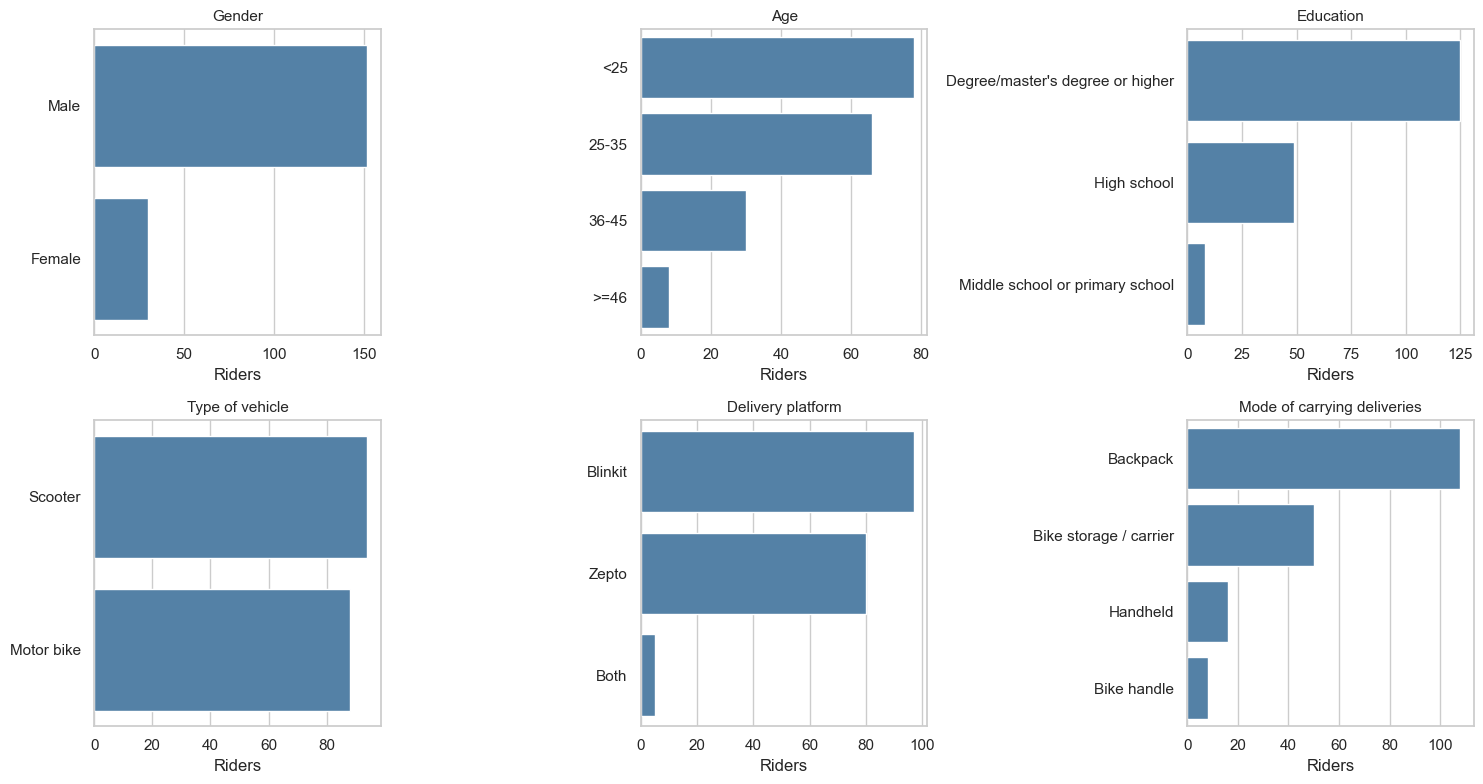

In [3]:
demo_cols = ['Gender', 'Age', 'Education',
             'Type of vehicle', 'Delivery platform', 'Mode of carrying deliveries']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, c in zip(axes.flat, demo_cols):
    vc = df[c].value_counts()
    sns.barplot(x=vc.values, y=vc.index, ax=ax, color='steelblue')
    ax.set_title(c, fontsize=11)
    ax.set_xlabel('Riders')
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIGS / 'demographics.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 3 — Risk factor distribution

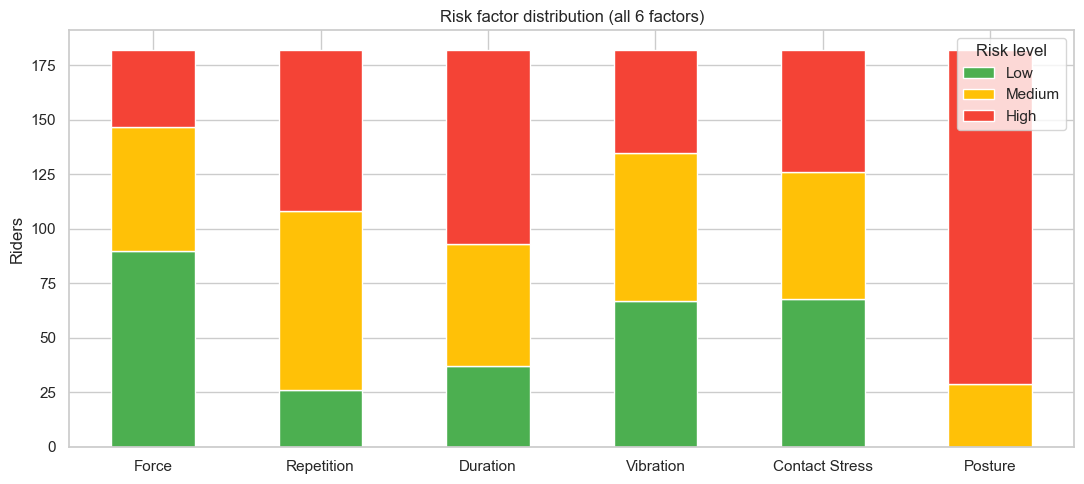

,Force,Repetition,Duration,Vibration,Contact Stress,Posture
Low,90,26,37,67,68,0
Medium,57,82,56,68,58,29
High,35,74,89,47,56,153


In [4]:
risk_factors = ['force_risk', 'repetition_risk', 'duration_risk',
                'vibration_risk', 'contact_stress_risk', 'posture_risk']
order = ['Low', 'Medium', 'High']

counts = pd.DataFrame({f: risk[f].value_counts() for f in risk_factors}).reindex(order).fillna(0).astype(int)
counts.columns = ['Force', 'Repetition', 'Duration', 'Vibration', 'Contact Stress', 'Posture']

fig, ax = plt.subplots(figsize=(11, 5))
counts.T.plot(kind='bar', stacked=True, ax=ax,
              color=['#4CAF50', '#FFC107', '#F44336'])
ax.set_ylabel('Riders')
ax.set_title('Risk factor distribution (all 6 factors)')
ax.legend(title='Risk level')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig(FIGS / 'risk_factor_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
counts

## Step 4 — Discomfort prevalence by body area (Nordic 12-month)

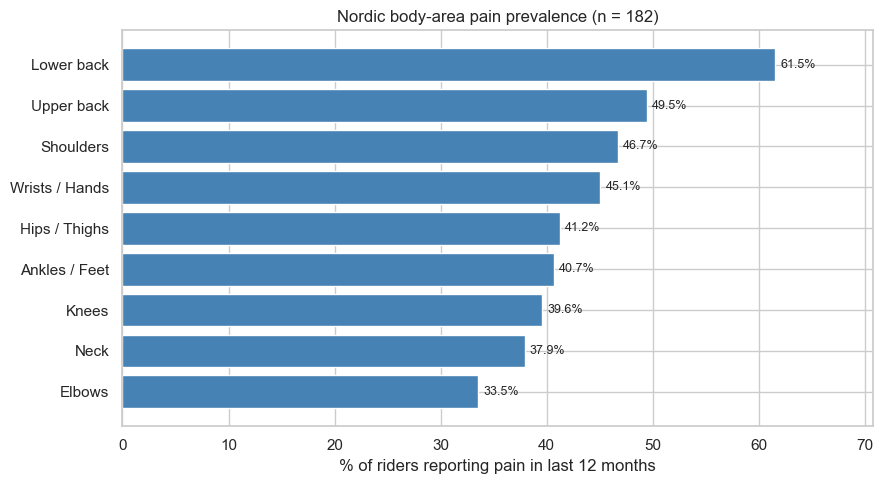

Overall discomfort prevalence (any body area): 84.6 %

Per-area prevalence (sorted, %):
Lower back        61.5
Upper back        49.5
Shoulders         46.7
Wrists / Hands    45.1
Hips / Thighs     41.2
Ankles / Feet     40.7
Knees             39.6
Neck              37.9
Elbows            33.5


In [5]:
# 9 Nordic body-area items, already 1/0 after Phase 2
nordic_cols = [c for c in df.columns if 'In the past 12 months' in c]

prev = df[nordic_cols].mean() * 100
# Strip the long survey header to just the body-area label
prev.index = [c.split('[')[-1].rstrip(']').replace('Row 1', '') for c in nordic_cols]
prev = prev.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(prev.index, prev.values, color='steelblue')
for bar, val in zip(bars, prev.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of riders reporting pain in last 12 months')
ax.set_title('Nordic body-area pain prevalence (n = 182)')
ax.set_xlim(0, prev.max() * 1.15)
plt.tight_layout()
plt.savefig(FIGS / 'nordic_prevalence.png', dpi=120, bbox_inches='tight')
plt.show()

print('Overall discomfort prevalence (any body area):',
      round(df['discomfort'].mean() * 100, 1), '%')
print()
print('Per-area prevalence (sorted, %):')
print(prev.sort_values(ascending=False).round(1).to_string())

## Step 5 — Discomfort prevalence by demographic group

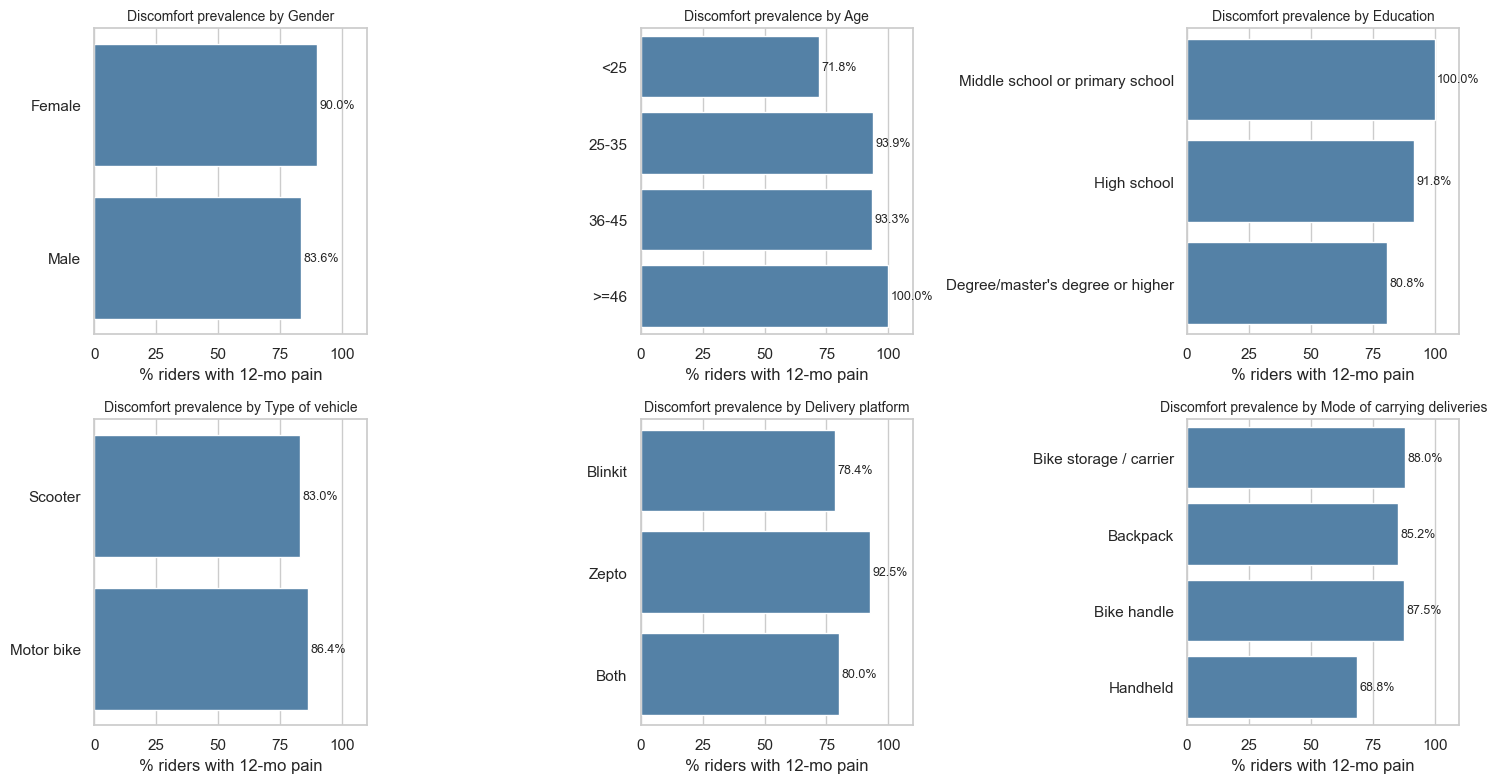

In [6]:
# Natural orders for categorical variables
orders = {
    'Gender': ['Female', 'Male'],
    'Age': ['<25', '25-35', '36-45', '>=46'],
    'Education': ['Middle school or primary school', 'High school', "Degree/master's degree or higher"],
    'Type of vehicle': ['Scooter', 'Motor bike'],
    'Delivery platform': ['Blinkit', 'Zepto', 'Both'],
    'Mode of carrying deliveries': ['Bike storage / carrier', 'Backpack', 'Bike handle', 'Handheld'],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, ordr) in zip(axes.flat, orders.items()):
    grp = (df.groupby(col)['discomfort'].mean() * 100).reindex(ordr)
    sns.barplot(x=grp.values, y=grp.index, ax=ax, color='steelblue')
    for i, v in enumerate(grp.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_title(f'Discomfort prevalence by {col}', fontsize=10)
    ax.set_xlabel('% riders with 12-mo pain')
    ax.set_ylabel('')
    ax.set_xlim(0, 110)
plt.tight_layout()
plt.savefig(FIGS / 'discomfort_by_demographic.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 6 — Discomfort prevalence vs each risk factor

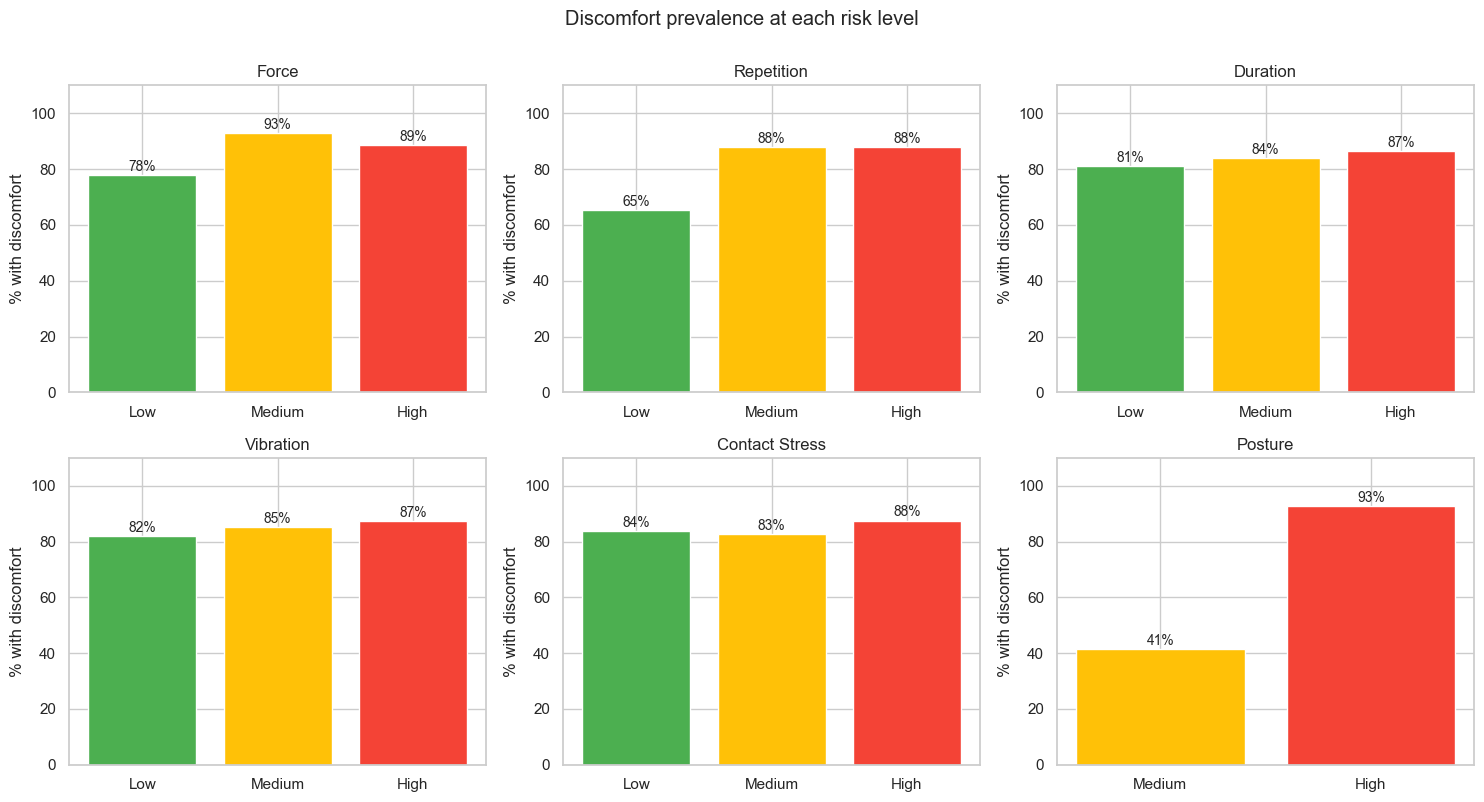

In [7]:
# Cross-tab of each risk factor with the discomfort outcome (preview of Phase 5)
merged = risk.assign(discomfort=df['discomfort'].values)
factor_labels = {'force_risk': 'Force', 'repetition_risk': 'Repetition',
                 'duration_risk': 'Duration', 'vibration_risk': 'Vibration',
                 'contact_stress_risk': 'Contact Stress', 'posture_risk': 'Posture'}
order = ['Low', 'Medium', 'High']
colors = ['#4CAF50', '#FFC107', '#F44336']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (factor, label) in zip(axes.flat, factor_labels.items()):
    prev = (merged.groupby(factor)['discomfort'].mean().reindex(order) * 100)
    levels = [lvl for lvl, val in prev.items() if not pd.isna(val)]
    vals   = [prev[lvl] for lvl in levels]
    cols   = [colors[order.index(lvl)] for lvl in levels]
    ax.bar(levels, vals, color=cols)
    for i, v in enumerate(vals):
        ax.text(i, v + 1.5, f'{v:.0f}%', ha='center', fontsize=10)
    ax.set_title(label)
    ax.set_xlabel('')
    ax.set_ylabel('% with discomfort')
    ax.set_ylim(0, 110)
plt.suptitle('Discomfort prevalence at each risk level', y=1.00)
plt.tight_layout()
plt.savefig(FIGS / 'risk_vs_discomfort.png', dpi=120, bbox_inches='tight')
plt.show()

## Step 7 — Correlation heatmap (numeric features and discomfort)

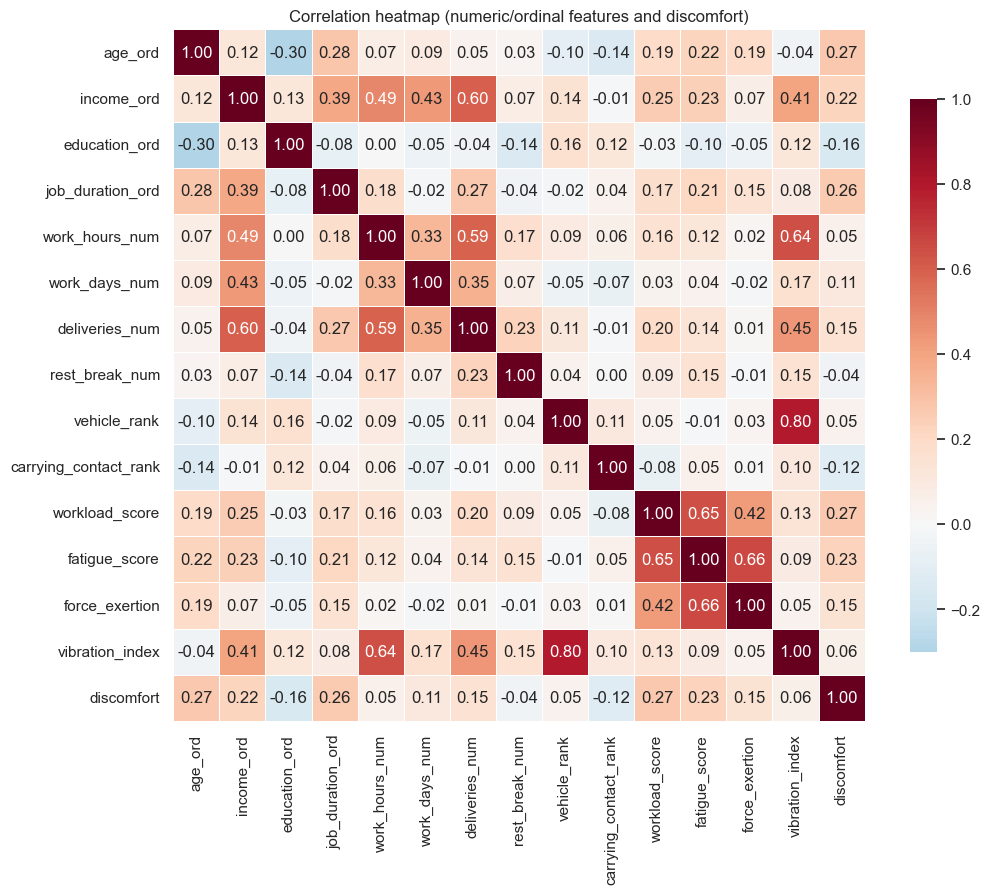

Top features correlated with discomfort (abs value):
workload_score           0.270
age_ord                  0.267
job_duration_ord         0.260
fatigue_score            0.231
income_ord               0.222
education_ord            0.162
deliveries_num           0.151
force_exertion           0.145
carrying_contact_rank    0.122
work_days_num            0.110
vibration_index          0.057
work_hours_num           0.052
vehicle_rank             0.047
rest_break_num           0.042


In [8]:
num_cols = ['age_ord', 'income_ord', 'education_ord', 'job_duration_ord',
            'work_hours_num', 'work_days_num', 'deliveries_num', 'rest_break_num',
            'vehicle_rank', 'carrying_contact_rank',
            'workload_score', 'fatigue_score', 'force_exertion', 'vibration_index',
            'discomfort']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=.5, cbar_kws={'shrink': .8}, ax=ax)
ax.set_title('Correlation heatmap (numeric/ordinal features and discomfort)')
plt.tight_layout()
plt.savefig(FIGS / 'correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Top features correlated with discomfort
print('Top features correlated with discomfort (abs value):')
print(corr['discomfort'].drop('discomfort').abs().sort_values(ascending=False).round(3).to_string())